In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.66MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.49MB/s]


In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)  # latent space
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)  # flatten
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)
criterion = nn.MSELoss()  # MSE loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
epochs = 10

for epoch in range(epochs):
    total_loss = 0

    for data, _ in train_loader:
        data = data.to(device)

        output = model(data)
        loss = criterion(output, data.view(-1, 784))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.0611
Epoch [2/10], Loss: 0.0308
Epoch [3/10], Loss: 0.0242
Epoch [4/10], Loss: 0.0210
Epoch [5/10], Loss: 0.0188
Epoch [6/10], Loss: 0.0170
Epoch [7/10], Loss: 0.0157
Epoch [8/10], Loss: 0.0147
Epoch [9/10], Loss: 0.0140
Epoch [10/10], Loss: 0.0133


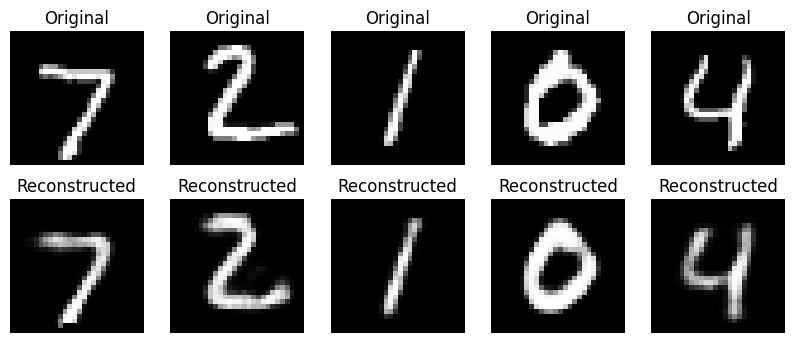

In [6]:
dataiter = iter(test_loader)
images, _ = next(dataiter)
images = images.to(device)

outputs = model(images)


images = images.cpu()
outputs = outputs.view(-1, 1, 28, 28).cpu()

plt.figure(figsize=(10,4))

# Original Images
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

# Reconstructed Images
for i in range(5):
    plt.subplot(2,5,i+6)
    plt.imshow(outputs[i].squeeze().detach(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()